# World Bank Data: Women's Barriers in the Labor Market — Latin America

In [4]:
import wbgapi as wb
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## Countries and Indicators

In [5]:
LATAM = [
    "ARG", "BOL", "BRA", "CHL", "COL", "CRI", "CUB", "DOM",
    "ECU", "SLV", "GTM", "HND", "MEX", "NIC", "PAN", "PRY",
    "PER", "URY", "VEN",
]

# Years of interest
YEARS = range(2020, 2025)

# Indicators grouped by theme
INDICATORS = {
    # --- Labor force participation ---
    "SL.TLF.CACT.FE.ZS": "Labor force participation rate, female (% of female population 15+)",
    "SL.TLF.CACT.MA.ZS": "Labor force participation rate, male (% of male population 15+)",
    "SL.TLF.CACT.FM.ZS": "Ratio female-to-male labor force participation rate (%)",

    # --- Unemployment ---
    "SL.UEM.TOTL.FE.ZS": "Unemployment rate, female (% of female labor force)",
    "SL.UEM.TOTL.MA.ZS": "Unemployment rate, male (% of male labor force)",

    # --- Employment quality ---
    "SL.EMP.VULN.FE.ZS": "Vulnerable employment, female (% of female employment)",
    "SL.EMP.VULN.MA.ZS": "Vulnerable employment, male (% of male employment)",
    "SL.EMP.SELF.FE.ZS": "Self-employed, female (% of female employment)",
    "SL.EMP.MPYR.FE.ZS": "Employers, female (% of female employment)",
    "SL.EMP.WORK.FE.ZS": "Wage & salaried workers, female (% of female employment)",

    # --- Sectoral employment ---
    "SL.AGR.EMPL.FE.ZS": "Employment in agriculture, female (% of female employment)",
    "SL.IND.EMPL.FE.ZS": "Employment in industry, female (% of female employment)",
    "SL.SRV.EMPL.FE.ZS": "Employment in services, female (% of female employment)",

    # --- Education (access barrier) ---
    "SE.ADT.LITR.FE.ZS": "Literacy rate, adult female (% of females 15+)",
    "SE.SEC.ENRR.FE":    "School enrollment, secondary, female (gross %)",
    "SE.TER.ENRR.FE":    "School enrollment, tertiary, female (gross %)",

    # --- Reproductive & household burden ---
    "SP.DYN.TFRT.IN":    "Fertility rate, total (births per woman)",
    "SH.STA.MMRT":       "Maternal mortality ratio (per 100,000 live births)",

    # --- Legal & institutional ---
    "SG.GEN.PARL.ZS":    "Proportion of seats held by women in national parliaments (%)",
    "IC.FRM.FEMM.ZS":    "Firms with female top manager (% of firms)",

    # --- Agriculture & Rural ---
    "AG.LND.AGRI.ZS":    "Agricultural land (% of land area)",
    # --- Human Capital Index Plus (HCI+) ---
    "HD_HCIP_EDUC_FE": "Human capital index plus (HCI+): education pillar score, female (scale 0-188)",
    "HD_HCIP_EDUC_MA": "Human capital index plus (HCI+): education pillar score, male (scale 0-188)",
    "HD_HCIP_EDUC_TO": "Human capital index plus (HCI+): education pillar score, total (scale 0-188)",
    "HD_HCIP_HLTH_FE": "Human capital index plus (HCI+): health pillar score, female (scale 0-50)",
    "HD_HCIP_HLTH_MA": "Human capital index plus (HCI+): health pillar score, male (scale 0-50)",
    "HD_HCIP_HLTH_TO": "Human capital index plus (HCI+): health pillar score, total (scale 0-50)",
    "HD_HCIP_OTJL_FE": "Human capital index plus (HCI+): on-the-job learning pillar score, female (scale -30-87)",
    "HD_HCIP_OTJL_MA": "Human capital index plus (HCI+): on-the-job learning pillar score, male (scale -30-87)",
    "HD_HCIP_OTJL_TO": "Human capital index plus (HCI+): on-the-job learning pillar score, total (scale -30-87)",
    "HD_HCIP_OVRL_FE": "Human capital index plus (HCI+): overall score, female (scale 0-325)",
    "HD_HCIP_OVRL_MA": "Human capital index plus (HCI+): overall score, male (scale 0-325)",
    "HD_HCIP_OVRL_TO": "Human capital index plus (HCI+): overall score, total (scale 0-325)",

    # --- Firms & Ownership ---
    "IC.FRM.FEMO.ZS":    "Firms with female participation in ownership (% of firms)",

    # --- Internet access ---
    "IT.NET.USER.FE.ZS": "Individuals using the Internet, female (% of female population)",
    "IT.NET.USER.MA.ZS": "Individuals using the Internet, male (% of male population)",

    # --- Literacy ---
    "SE.ADT.LITR.MA.ZS": "Literacy rate, adult male (% of males ages 15 and above)",

    # --- Learning poverty ---
    "SE.LPV.PRIM.FE":    "Learning poverty: Share of Female Children at End-of-Primary below minimum reading proficiency (%)",
    "SE.LPV.PRIM.MA":    "Learning poverty: Share of Male Children at End-of-Primary below minimum reading proficiency (%)",
    "SE.LPV.PRIM.SD.FE": "Female primary school age children out-of-school (%)",
    "SE.LPV.PRIM.SD.MA": "Male primary school age children out-of-school (%)",

    # --- Pre-primary enrollment ---
    "SE.PRE.ENRR":       "School enrollment, preprimary (% gross)",
    "SE.PRE.ENRR.FE":    "School enrollment, preprimary, female (% gross)",

    # --- Primary education ---
    "SE.PRM.CMPT.FE.ZS": "Primary completion rate, female (% of relevant age group)",
    "SE.PRM.CMPT.MA.ZS": "Primary completion rate, male (% of relevant age group)",
    "SE.PRM.CUAT.FE.ZS": "Educational attainment, at least completed primary, population 25+, female (%) (cumulative)",
    "SE.PRM.CUAT.MA.ZS": "Educational attainment, at least completed primary, population 25+, male (%) (cumulative)",
    "SE.PRM.PRSL.FE.ZS": "Persistence to last grade of primary, female (% of cohort)",
    "SE.PRM.PRSL.MA.ZS": "Persistence to last grade of primary, male (% of cohort)",
    "SE.PRM.UNER.FE.ZS": "Children out of school, female (% of female primary school age)",
    "SE.PRM.UNER.MA.ZS": "Children out of school, male (% of male primary school age)",

    # --- Secondary education ---
    "SE.SEC.CUAT.UP.FE.ZS": "Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)",
    "SE.SEC.CUAT.UP.MA.ZS": "Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)",
    "SE.SEC.DURS":           "Secondary education, duration (years)",
    "SE.SEC.UNER.LO.FE.ZS": "Adolescents out of school, female (% of female lower secondary school age)",
    "SE.SEC.UNER.LO.MA.ZS": "Adolescents out of school, male (% of male lower secondary school age)",

    # --- Tertiary education ---
    "SE.TER.CUAT.BA.FE.ZS": "Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative)",
    "SE.TER.CUAT.BA.MA.ZS": "Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative)",
    "SE.TER.CUAT.DO.FE.ZS": "Educational attainment, Doctoral or equivalent, population 25+, female (%) (cumulative)",
    "SE.TER.CUAT.DO.MA.ZS": "Educational attainment, Doctoral or equivalent, population 25+, male (%) (cumulative)",
    "SE.TER.CUAT.MS.FE.ZS": "Educational attainment, at least Master's or equivalent, population 25+, female (%) (cumulative)",
    "SE.TER.CUAT.MS.MA.ZS": "Educational attainment, at least Master's or equivalent, population 25+, male (%) (cumulative)",

    # --- Unpaid care work ---
    "SG.TIM.UWRK.FE":    "Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)",
    "SG.TIM.UWRK.MA":    "Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)",

    # --- Child employment ---
    "SL.AGR.0714.FE.ZS": "Child employment in agriculture, female (% of female economically active children ages 7-14)",
    "SL.AGR.0714.MA.ZS": "Child employment in agriculture, male (% of male economically active children ages 7-14)",
    "SL.FAM.0714.FE.ZS": "Children in employment, unpaid family workers, female (% of female children in employment, ages 7-14)",
    "SL.FAM.0714.MA.ZS": "Children in employment, unpaid family workers, male (% of male children in employment, ages 7-14)",

    # --- Employment (additional) ---
    "SL.EMP.MPYR.MA.ZS": "Employers, male (% of male employment) (modeled ILO estimate)",
    "SL.EMP.SELF.MA.ZS": "Self-employed, male (% of male employment) (modeled ILO estimate)",
    "SL.EMP.SMGT.FE.ZS": "Female share of employment in senior and middle management (%)",
    "SL.EMP.WORK.MA.ZS": "Wage and salaried workers, male (% of male employment) (modeled ILO estimate)",
    "SL.FAM.WORK.FE.ZS": "Contributing family workers, female (% of female employment) (modeled ILO estimate)",
    "SL.FAM.WORK.MA.ZS": "Contributing family workers, male (% of male employment) (modeled ILO estimate)",
    "SL.IND.EMPL.MA.ZS": "Employment in industry, male (% of male employment) (modeled ILO estimate)",
    "SL.SRV.EMPL.MA.ZS": "Employment in services, male (% of male employment) (modeled ILO estimate)",

    # --- Labor force (additional) ---
    "SL.TLF.ACTI.FE.ZS": "Labor force participation rate, female (% of female population ages 15-64) (modeled ILO estimate)",
    "SL.TLF.ACTI.MA.ZS": "Labor force participation rate, male (% of male population ages 15-64) (modeled ILO estimate)",
    "SL.TLF.ADVN.FE.ZS": "Labor force with advanced education, female (% of female working-age population with advanced education)",
    "SL.TLF.ADVN.MA.ZS": "Labor force with advanced education, male (% of male working-age population with advanced education)",
    "SL.TLF.BASC.FE.ZS": "Labor force with basic education, female (% of female working-age population with basic education)",
    "SL.TLF.BASC.MA.ZS": "Labor force with basic education, male (% of male working-age population with basic education)",
    "SL.TLF.INTM.FE.ZS": "Labor force with intermediate education, female (% of female working-age population with intermediate education)",
    "SL.TLF.INTM.MA.ZS": "Labor force with intermediate education, male (% of male working-age population with intermediate education)",
    "SL.TLF.PART.FE.ZS": "Part time employment, female (% of total female employment)",
    "SL.TLF.PART.MA.ZS": "Part time employment, male (% of total male employment)",

    # --- Household & family ---
    "SP.HOU.FEMA.ZS":    "Female headed households (% of households with a female head)",

    # --- Reproductive health ---
    "SH.FPL.SATM.ZS":    "Demand for family planning satisfied by modern methods (% of married women with demand for family planning)",
    "SP.ADO.TFRT":        "Adolescent fertility rate (births per 1,000 women ages 15-19)",
    "SP.MTR.1519.ZS":     "Teenage mothers (% of women ages 15-19 who have had children or are currently pregnant)",

    # --- Legal & institutional (additional) ---
    "SG.LAW.INDX":        "Women Business and the Law Index Score (scale 1-100)",
}

## Fetch data from World Bank API

In [6]:
def fetch_indicators(indicators: dict, countries: list, years) -> pd.DataFrame:
    """Fetch multiple WB indicators and return a tidy long-format DataFrame."""
    frames = []
    for code, label in indicators.items():
        try:
            df = wb.data.DataFrame(
                code,
                economy=countries,
                time=years,
                labels=True,      # adds human-readable country names
                skipBlanks=True,
            )
            # wb returns wide format: rows = countries, columns = years
            df = df.reset_index()
            df = df.melt(
                id_vars=["economy", "Country"],
                var_name="year",
                value_name="value",
            )
            df["indicator_code"] = code
            df["indicator_name"] = label
            frames.append(df)
        except Exception as e:
            print(f"Could not fetch {code}: {e}")

    result = pd.concat(frames, ignore_index=True)
    result["year"] = result["year"].str.replace("YR", "").astype(int)
    result = result.rename(columns={"economy": "country_code", "Country": "country_name"})
    return result[["country_code", "country_name", "year", "indicator_code", "indicator_name", "value"]]


df_raw = fetch_indicators(INDICATORS, LATAM, YEARS)
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Could not fetch SL.TLF.CACT.FM.ZS: APIError: [400] Bad Request (https://api.worldbank.org/v2/en/sources/2/series/SL.TLF.CACT.FM.ZS/country/ARG;BOL;BRA;CHL;COL;CRI;CUB;DOM;ECU;SLV;GTM;HND;MEX;NIC;PAN;PRY;PER;URY;VEN/time/YR2020;YR2021;YR2022;YR2023;YR2024?per_page=1000&page=1&format=json)
Could not fetch SE.LPV.PRIM.FE: "The following id_vars or value_vars are not present in the DataFrame: ['Country']"
Could not fetch SE.LPV.PRIM.MA: "The following id_vars or value_vars are not present in the DataFrame: ['Country']"
Could not fetch SE.LPV.PRIM.SD.FE: "The following id_vars or value_vars are not present in the DataFrame: ['Country']"
Could not fetch SE.LPV.PRIM.SD.MA: "The following id_vars or value_vars are not present in the DataFrame: ['Country']"
Could not fetch SL.AGR.0714.FE.ZS: "The following id_vars or value_vars are not present in the DataFrame: ['Country']"
Could not fetch SL.AGR.0714.MA.ZS: "The following id_vars or value_vars are not present in the DataFrame: ['Country']"
Cou

,country_code,country_name,year,indicator_code,indicator_name,value
0,VEN,"Venezuela, RB",2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",36.89
1,URY,Uruguay,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",54.23
2,PER,Peru,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",59.86
3,PRY,Paraguay,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",57.10
4,PAN,Panama,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",55.93
5,NIC,Nicaragua,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",48.12
6,MEX,Mexico,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",41.70
7,HND,Honduras,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",47.04
8,GTM,Guatemala,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",38.30
9,SLV,El Salvador,2020,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",43.21


## Explore coverage

In [7]:
# Non-null observations per indicator
coverage = (
    df_raw.dropna(subset=["value"])
    .groupby(["indicator_code", "indicator_name"])
    .agg(non_null_obs=("value", "count"), countries=("country_code", "nunique"))
    .reset_index()
    .sort_values("non_null_obs", ascending=False)
)
coverage

,indicator_code,indicator_name,non_null_obs,countries
58,SL.FAM.WORK.MA.ZS,"Contributing family workers, male (% of male e...",95,19
60,SL.IND.EMPL.MA.ZS,"Employment in industry, male (% of male employ...",95,19
51,SL.EMP.SELF.MA.ZS,"Self-employed, male (% of male employment) (mo...",95,19
53,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",95,19
54,SL.EMP.VULN.MA.ZS,"Vulnerable employment, male (% of male employm...",95,19
...,...,...,...,...
37,SE.TER.CUAT.DO.FE.ZS,"Educational attainment, Doctoral or equivalent...",15,7
13,IC.FRM.FEMM.ZS,Firms with female top manager (% of firms),8,8
14,IC.FRM.FEMO.ZS,Firms with female participation in ownership (...,8,8
44,SG.TIM.UWRK.FE,Proportion of time spent on unpaid domestic an...,2,2


## Wide-format snapshot — latest available year per country

In [8]:
# For each country + indicator, keep the most recent non-null value
latest = (
    df_raw.dropna(subset=["value"])
    .sort_values("year", ascending=False)
    .groupby(["country_code", "country_name", "indicator_code"], as_index=False)
    .first()
)

# Pivot so each indicator is a column
df_wide = latest.pivot_table(
    index=["country_code", "country_name"],
    columns="indicator_code",
    values="value",
)
df_wide.columns.name = None
df_wide = df_wide.reset_index()
df_wide

,country_code,country_name,AG.LND.AGRI.ZS,HD_HCIP_EDUC_FE,HD_HCIP_EDUC_MA,HD_HCIP_EDUC_TO,HD_HCIP_HLTH_FE,HD_HCIP_HLTH_MA,HD_HCIP_HLTH_TO,HD_HCIP_OTJL_FE,HD_HCIP_OTJL_MA,HD_HCIP_OTJL_TO,HD_HCIP_OVRL_FE,HD_HCIP_OVRL_MA,HD_HCIP_OVRL_TO,IC.FRM.FEMM.ZS,IC.FRM.FEMO.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,SE.ADT.LITR.FE.ZS,SE.ADT.LITR.MA.ZS,SE.PRE.ENRR,SE.PRE.ENRR.FE,SE.PRM.CMPT.FE.ZS,SE.PRM.CMPT.MA.ZS,SE.PRM.CUAT.FE.ZS,SE.PRM.CUAT.MA.ZS,SE.PRM.PRSL.FE.ZS,SE.PRM.PRSL.MA.ZS,SE.PRM.UNER.FE.ZS,SE.PRM.UNER.MA.ZS,SE.SEC.CUAT.UP.FE.ZS,SE.SEC.CUAT.UP.MA.ZS,SE.SEC.DURS,SE.SEC.ENRR.FE,SE.SEC.UNER.LO.FE.ZS,SE.SEC.UNER.LO.MA.ZS,SE.TER.CUAT.BA.FE.ZS,SE.TER.CUAT.BA.MA.ZS,SE.TER.CUAT.DO.FE.ZS,SE.TER.CUAT.DO.MA.ZS,SE.TER.CUAT.MS.FE.ZS,SE.TER.CUAT.MS.MA.ZS,SE.TER.ENRR.FE,SG.GEN.PARL.ZS,SG.LAW.INDX,SG.TIM.UWRK.FE,SG.TIM.UWRK.MA,SH.STA.MMRT,SL.AGR.EMPL.FE.ZS,SL.EMP.MPYR.FE.ZS,SL.EMP.MPYR.MA.ZS,SL.EMP.SELF.FE.ZS,SL.EMP.SELF.MA.ZS,SL.EMP.SMGT.FE.ZS,SL.EMP.VULN.FE.ZS,SL.EMP.VULN.MA.ZS,SL.EMP.WORK.FE.ZS,SL.EMP.WORK.MA.ZS,SL.FAM.WORK.FE.ZS,SL.FAM.WORK.MA.ZS,SL.IND.EMPL.FE.ZS,SL.IND.EMPL.MA.ZS,SL.SRV.EMPL.FE.ZS,SL.SRV.EMPL.MA.ZS,SL.TLF.ACTI.FE.ZS,SL.TLF.ACTI.MA.ZS,SL.TLF.ADVN.FE.ZS,SL.TLF.ADVN.MA.ZS,SL.TLF.BASC.FE.ZS,SL.TLF.BASC.MA.ZS,SL.TLF.CACT.FE.ZS,SL.TLF.CACT.MA.ZS,SL.TLF.INTM.FE.ZS,SL.TLF.INTM.MA.ZS,SL.TLF.PART.FE.ZS,SL.TLF.PART.MA.ZS,SL.UEM.TOTL.FE.ZS,SL.UEM.TOTL.MA.ZS,SP.ADO.TFRT,SP.DYN.TFRT.IN
0,ARG,Argentina,42.44,113.79,105.56,109.75,45.89,44.03,44.95,29.81,50.64,39.98,189.49,200.24,194.67,NaN,NaN,89.03,89.44,99.16,99.13,76.19,76.71,99.92,98.02,NaN,NaN,95.28,96.01,NaN,NaN,NaN,NaN,6.00,107.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.19,42.41,79.38,NaN,NaN,33.00,3.77,2.29,4.05,22.92,27.81,36.39,20.63,23.75,77.08,72.19,0.41,0.20,9.77,29.53,86.45,60.64,61.47,79.43,74.04,85.31,32.67,58.58,52.28,71.77,54.48,73.21,55.63,30.56,7.91,6.58,26.41,1.50
1,BOL,Bolivia,35.83,NaN,NaN,NaN,42.11,39.55,40.80,30.05,48.38,39.06,NaN,NaN,NaN,NaN,NaN,63.71,68.32,93.50,97.77,78.47,79.06,96.31,96.10,65.93,76.77,97.01,96.74,3.93,4.37,50.91,56.85,6.00,91.29,7.23,7.56,20.13,20.10,0.05,0.07,1.35,1.87,NaN,46.15,88.75,NaN,NaN,146.00,24.81,2.05,4.89,70.04,63.47,22.27,67.99,58.58,29.96,36.53,24.05,10.58,12.38,26.46,62.80,48.52,74.34,85.87,82.32,91.95,67.19,79.66,72.39,84.32,70.82,84.69,50.66,29.31,3.68,2.92,64.85,2.55
2,BRA,Brazil,28.33,115.88,111.20,102.33,46.08,42.94,44.49,30.27,49.03,39.58,192.23,203.18,186.40,NaN,NaN,85.66,82.55,95.09,94.49,85.94,85.73,NaN,NaN,86.74,84.81,NaN,NaN,3.70,4.25,63.12,60.21,7.00,108.78,2.43,5.15,NaN,NaN,NaN,NaN,NaN,NaN,71.93,17.54,85.00,NaN,NaN,67.00,3.23,2.96,5.08,24.86,34.70,38.13,21.90,29.62,75.14,65.30,1.90,0.81,10.61,27.50,86.17,61.45,61.39,80.73,77.97,88.03,37.09,64.87,53.58,73.60,64.14,84.08,32.71,19.49,8.37,5.60,42.69,1.62
3,CHL,Chile,14.40,133.11,130.29,131.67,47.73,46.11,46.92,32.00,50.83,41.48,212.84,227.24,220.08,NaN,NaN,93.20,95.10,NaN,NaN,84.51,83.75,99.20,102.56,91.74,93.38,97.43,100.00,2.23,0.46,69.40,70.31,6.00,104.63,1.49,0.11,21.71,22.86,0.14,0.33,3.02,3.60,114.00,35.48,80.00,NaN,NaN,10.00,3.48,1.75,3.90,22.86,24.92,31.60,21.11,21.02,77.14,75.08,0.80,0.46,10.48,29.94,86.04,61.81,61.79,79.39,79.95,89.94,29.62,55.78,52.78,72.02,57.13,76.20,36.78,23.05,9.51,8.13,6.54,1.17
4,COL,Colombia,36.49,108.14,104.91,106.50,45.71,43.06,44.38,23.55,49.23,36.02,177.39,197.19,186.90,24.60,62.50,73.59,71.96,95.69,94.97,85.93,86.67,96.75,97.47,83.61,82.48,92.94,89.84,6.79,7.84,58.97,58.65,6.00,103.59,3.71,5.14,17.94,17.38,0.12,0.21,4.63,4.56,64.32,29.41,84.38,17.64,5.24,59.00,5.92,1.89,3.17,42.79,47.76,43.49,40.90,44.60,57.21,52.24,3.14,1.23,13.31,24.60,80.77,55.46,57.53,80.67,76.37,87.00,35.80,66.90,51.72,75.86,56.16,81.09,30.79,16.14,11.91,7.99,59.47,1.65
5,CRI,Costa Rica,33.14,109.21,104.52,106.93,46.71,44.48,45.58,26.23,54.05,40.28,182.15,203.05,192.80,25.26,53.01,85.45,84.77,NaN,NaN,95.24,95.76,101.24,100.12,86.57,86.81,97.87,96.95,4.96,4.51,44.02,41.30,5.00,130.60,6.33,6.38,22.53,20.54,0.13,0.33,2.75,2.99,NaN,49.12,91.88,NaN,NaN,24.00,6.50,2.35,3.7

## Save to CSV

In [9]:
import os

output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")
os.makedirs(output_dir, exist_ok=True)

df_raw.to_csv(os.path.join(output_dir, "wb_women_latam_long.csv"), index=False)
df_wide.to_csv(os.path.join(output_dir, "wb_women_latam_wide.csv"), index=False)

print("Saved:")
print(f"  Long format : {df_raw.shape}  → data/wb_women_latam_long.csv")
print(f"  Wide format : {df_wide.shape} → data/wb_women_latam_wide.csv")

Saved:
  Long format : (5152, 6)  → data/wb_women_latam_long.csv
  Wide format : (19, 81) → data/wb_women_latam_wide.csv


## Visualizations

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"female": "#c2527a", "male": "#4a7fb5", "gap": "#e08c3a"}

# Helper: get latest value for a single indicator across all countries
def get_latest(indicator_code: str) -> pd.DataFrame:
    return (
        df_raw[df_raw["indicator_code"] == indicator_code]
        .dropna(subset=["value"])
        .sort_values("year", ascending=False)
        .groupby(["country_code", "country_name"], as_index=False)
        .first()
    )

### 1. Female vs Male Labor Force Participation — by country (latest year)

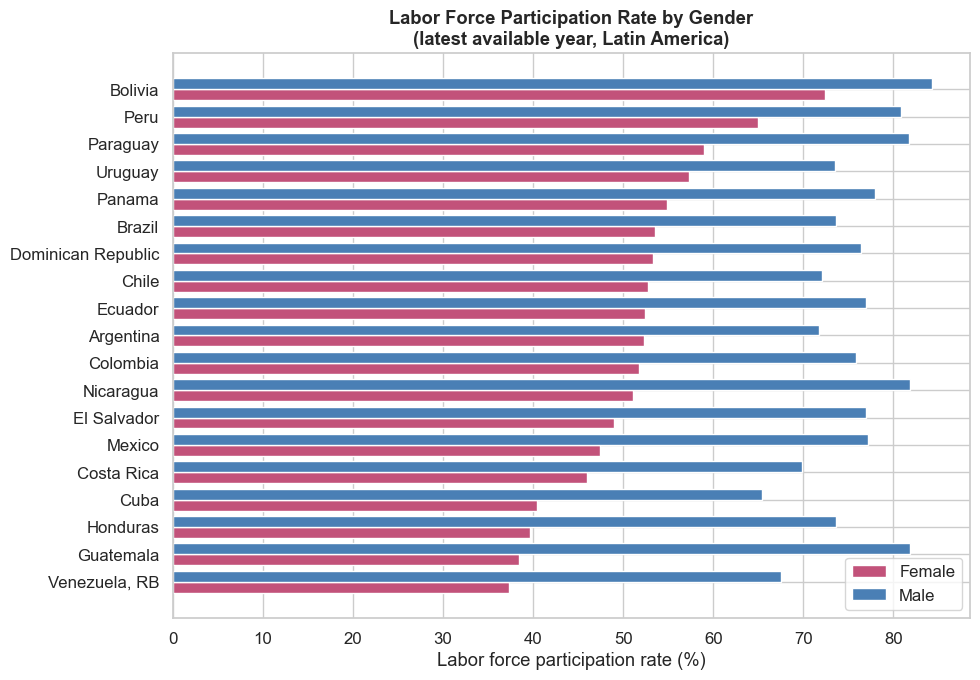

In [12]:
lfp_f = get_latest("SL.TLF.CACT.FE.ZS").set_index("country_name")["value"].rename("female")
lfp_m = get_latest("SL.TLF.CACT.MA.ZS").set_index("country_name")["value"].rename("male")
lfp = pd.concat([lfp_f, lfp_m], axis=1).dropna().sort_values("female")

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(lfp))
ax.barh([i - 0.2 for i in y], lfp["female"], height=0.4, color=COLORS["female"], label="Female")
ax.barh([i + 0.2 for i in y], lfp["male"],   height=0.4, color=COLORS["male"],   label="Male")
ax.set_yticks(list(y))
ax.set_yticklabels(lfp.index)
ax.set_xlabel("Labor force participation rate (%)")
ax.set_title("Labor Force Participation Rate by Gender\n(latest available year, Latin America)", fontweight="bold")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

### 2. Gender gap in labor force participation over time — regional trend

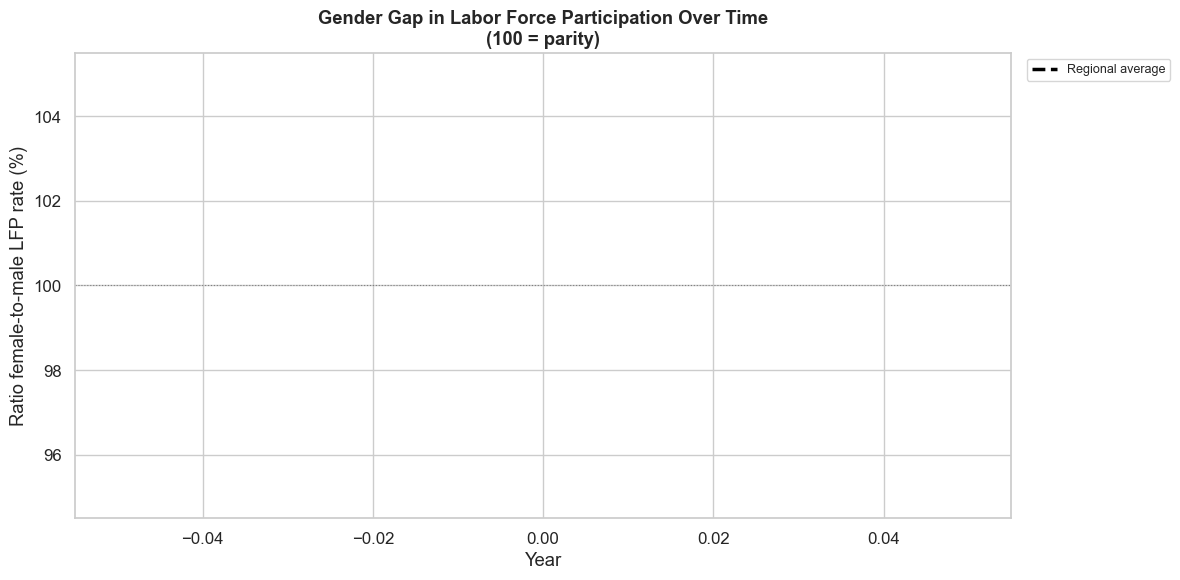

In [13]:
HIGHLIGHT = ["Brazil", "Mexico", "Argentina", "Colombia", "Guatemala", "Bolivia"]

gap_ts = (
    df_raw[df_raw["indicator_code"] == "SL.TLF.CACT.FM.ZS"]
    .dropna(subset=["value"])
    .groupby(["country_name", "year"])["value"]
    .mean()
    .reset_index()
)

# Regional average
regional_avg = gap_ts.groupby("year")["value"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for country in HIGHLIGHT:
    data = gap_ts[gap_ts["country_name"] == country]
    if not data.empty:
        ax.plot(data["year"], data["value"], marker="o", markersize=3, linewidth=1.5, label=country)

ax.plot(regional_avg["year"], regional_avg["value"], color="black",
        linewidth=2.5, linestyle="--", label="Regional average")
ax.axhline(100, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio female-to-male LFP rate (%)")
ax.set_title("Gender Gap in Labor Force Participation Over Time\n(100 = parity)", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### 3. Female vs Male Unemployment rate — scatter plot

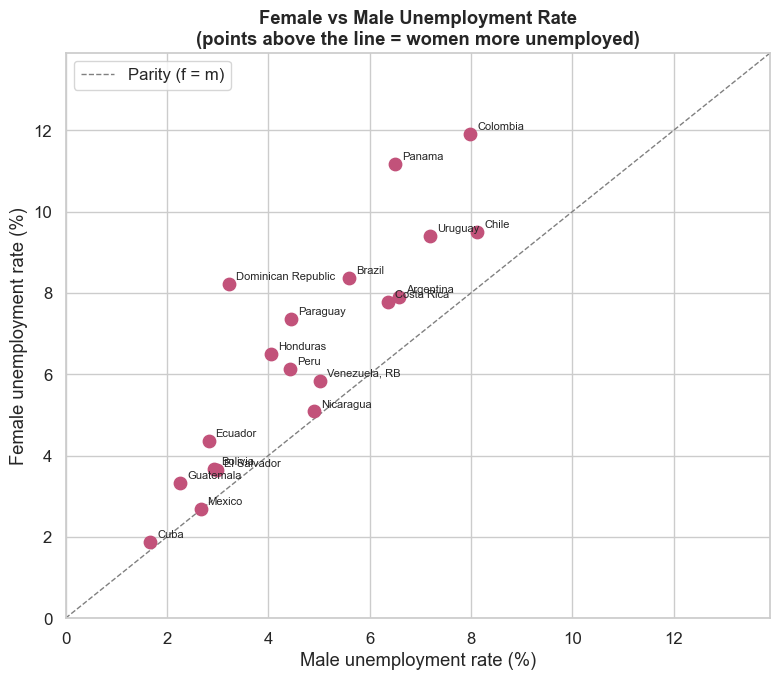

In [14]:
unem_f = get_latest("SL.UEM.TOTL.FE.ZS").set_index("country_name")["value"].rename("female")
unem_m = get_latest("SL.UEM.TOTL.MA.ZS").set_index("country_name")["value"].rename("male")
unem = pd.concat([unem_f, unem_m], axis=1).dropna()

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(unem["male"], unem["female"], color=COLORS["female"], s=80, zorder=3)
for country, row in unem.iterrows():
    ax.annotate(country, (row["male"], row["female"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

# Parity line
lim = max(unem.max()) + 2
ax.plot([0, lim], [0, lim], color="grey", linewidth=1, linestyle="--", label="Parity (f = m)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Male unemployment rate (%)")
ax.set_ylabel("Female unemployment rate (%)")
ax.set_title("Female vs Male Unemployment Rate\n(points above the line = women more unemployed)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 4. Vulnerable employment — female vs male by country

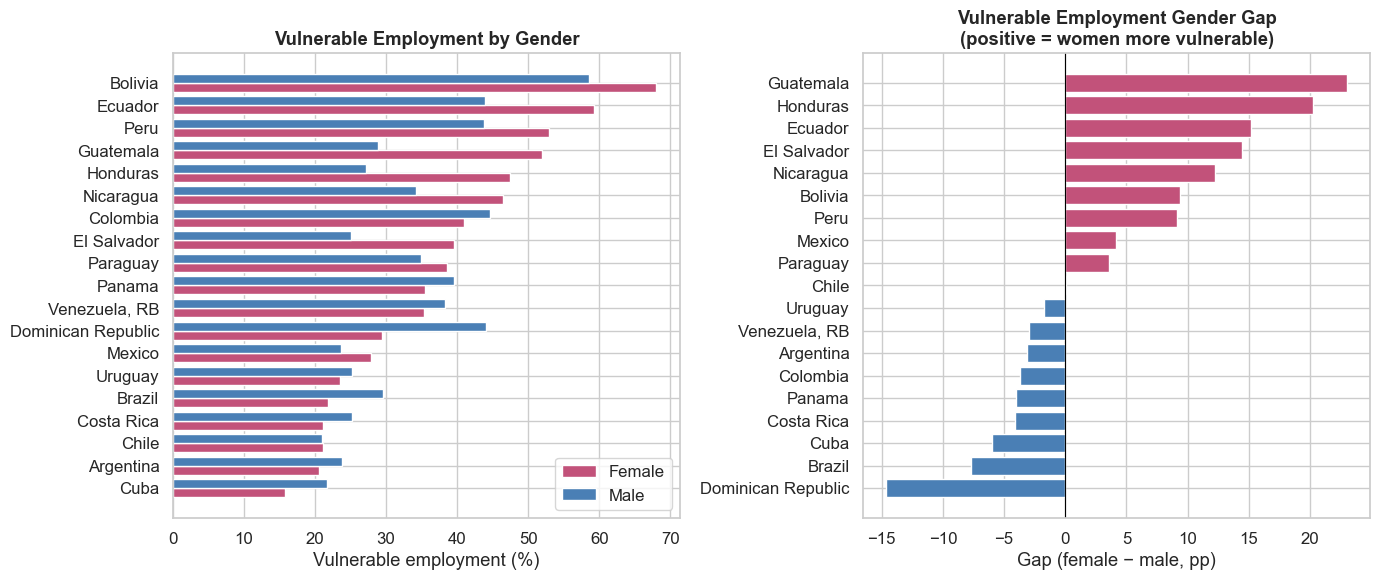

In [15]:
vuln_f = get_latest("SL.EMP.VULN.FE.ZS").set_index("country_name")["value"].rename("female")
vuln_m = get_latest("SL.EMP.VULN.MA.ZS").set_index("country_name")["value"].rename("male")
vuln = pd.concat([vuln_f, vuln_m], axis=1).dropna()
vuln["gap"] = vuln["female"] - vuln["male"]
vuln = vuln.sort_values("female")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: grouped bars
y = range(len(vuln))
axes[0].barh([i - 0.2 for i in y], vuln["female"], height=0.4, color=COLORS["female"], label="Female")
axes[0].barh([i + 0.2 for i in y], vuln["male"],   height=0.4, color=COLORS["male"],   label="Male")
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(vuln.index)
axes[0].set_xlabel("Vulnerable employment (%)")
axes[0].set_title("Vulnerable Employment by Gender", fontweight="bold")
axes[0].legend()

# Right: gap (female − male)
gap_sorted = vuln["gap"].sort_values()
colors = [COLORS["female"] if v > 0 else COLORS["male"] for v in gap_sorted]
axes[1].barh(gap_sorted.index, gap_sorted.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Gap (female − male, pp)")
axes[1].set_title("Vulnerable Employment Gender Gap\n(positive = women more vulnerable)", fontweight="bold")

plt.tight_layout()
plt.show()

### 5. Female sectoral employment composition — stacked bar

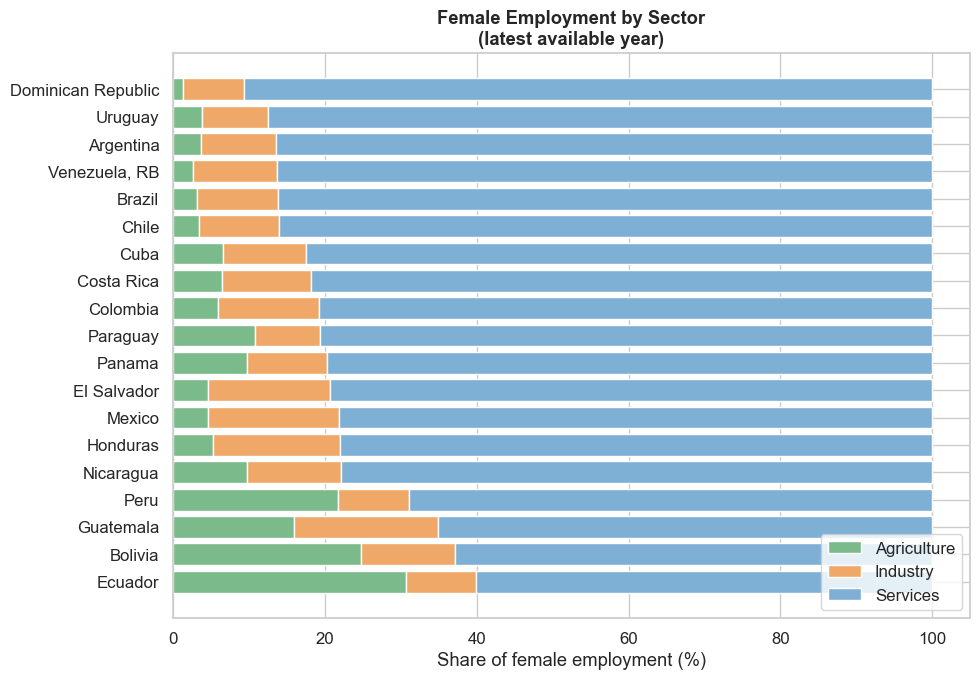

In [16]:
sector_codes = {
    "SL.AGR.EMPL.FE.ZS": "Agriculture",
    "SL.IND.EMPL.FE.ZS": "Industry",
    "SL.SRV.EMPL.FE.ZS": "Services",
}
sector_frames = {label: get_latest(code).set_index("country_name")["value"]
                 for code, label in sector_codes.items()}
sectors = pd.DataFrame(sector_frames).dropna()
sectors = sectors.sort_values("Services", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bottom = pd.Series(0, index=sectors.index)
palette = ["#7bba8a", "#f0a868", "#7eb0d5"]
for col, color in zip(["Agriculture", "Industry", "Services"], palette):
    ax.barh(sectors.index, sectors[col], left=bottom, color=color, label=col)
    bottom += sectors[col]

ax.set_xlabel("Share of female employment (%)")
ax.set_title("Female Employment by Sector\n(latest available year)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6. Women in parliament — evolution over time

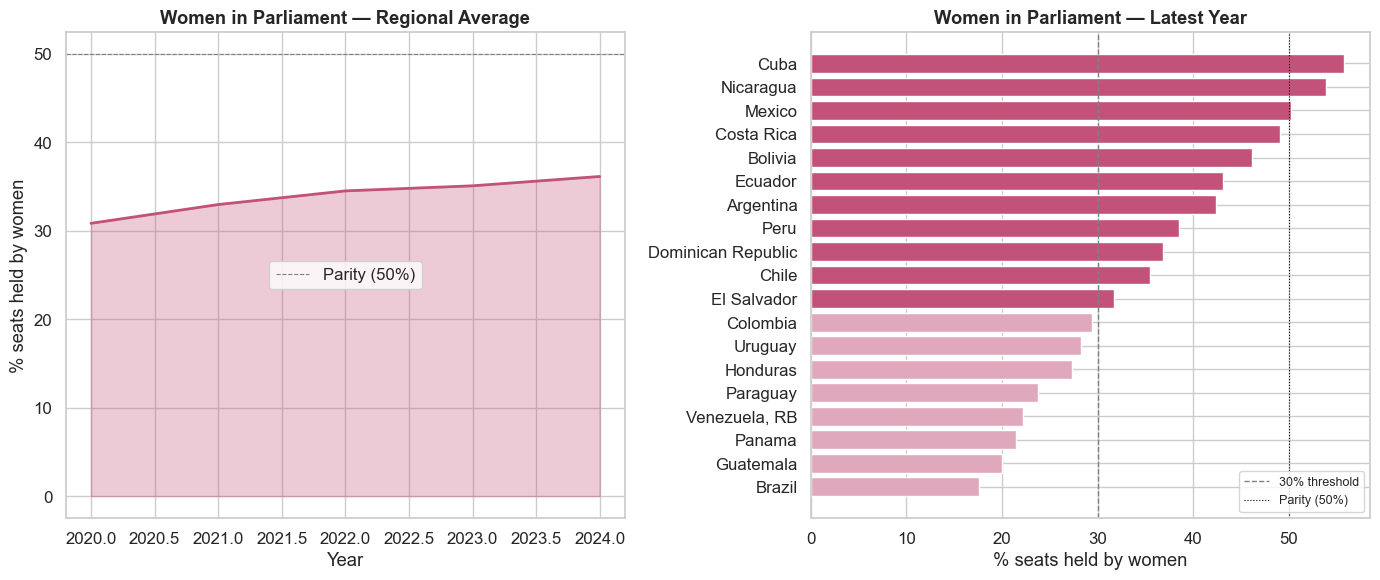

In [17]:
parl = (
    df_raw[df_raw["indicator_code"] == "SG.GEN.PARL.ZS"]
    .dropna(subset=["value"])
)
parl_avg = parl.groupby("year")["value"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: regional average over time
axes[0].fill_between(parl_avg["year"], parl_avg["value"], alpha=0.3, color=COLORS["female"])
axes[0].plot(parl_avg["year"], parl_avg["value"], color=COLORS["female"], linewidth=2)
axes[0].axhline(50, color="grey", linewidth=0.8, linestyle="--", label="Parity (50%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% seats held by women")
axes[0].set_title("Women in Parliament — Regional Average", fontweight="bold")
axes[0].legend()

# Right: latest value per country
latest_parl = (
    parl.sort_values("year", ascending=False)
    .groupby("country_name", as_index=False)
    .first()
    .sort_values("value")
)
bar_colors = [COLORS["female"] if v >= 30 else "#e0a8bc" for v in latest_parl["value"]]
axes[1].barh(latest_parl["country_name"], latest_parl["value"], color=bar_colors)
axes[1].axvline(30, color="grey", linewidth=1, linestyle="--", label="30% threshold")
axes[1].axvline(50, color="black", linewidth=0.8, linestyle=":", label="Parity (50%)")
axes[1].set_xlabel("% seats held by women")
axes[1].set_title("Women in Parliament — Latest Year", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 7. Correlation heatmap — all indicators (latest year, cross-country)

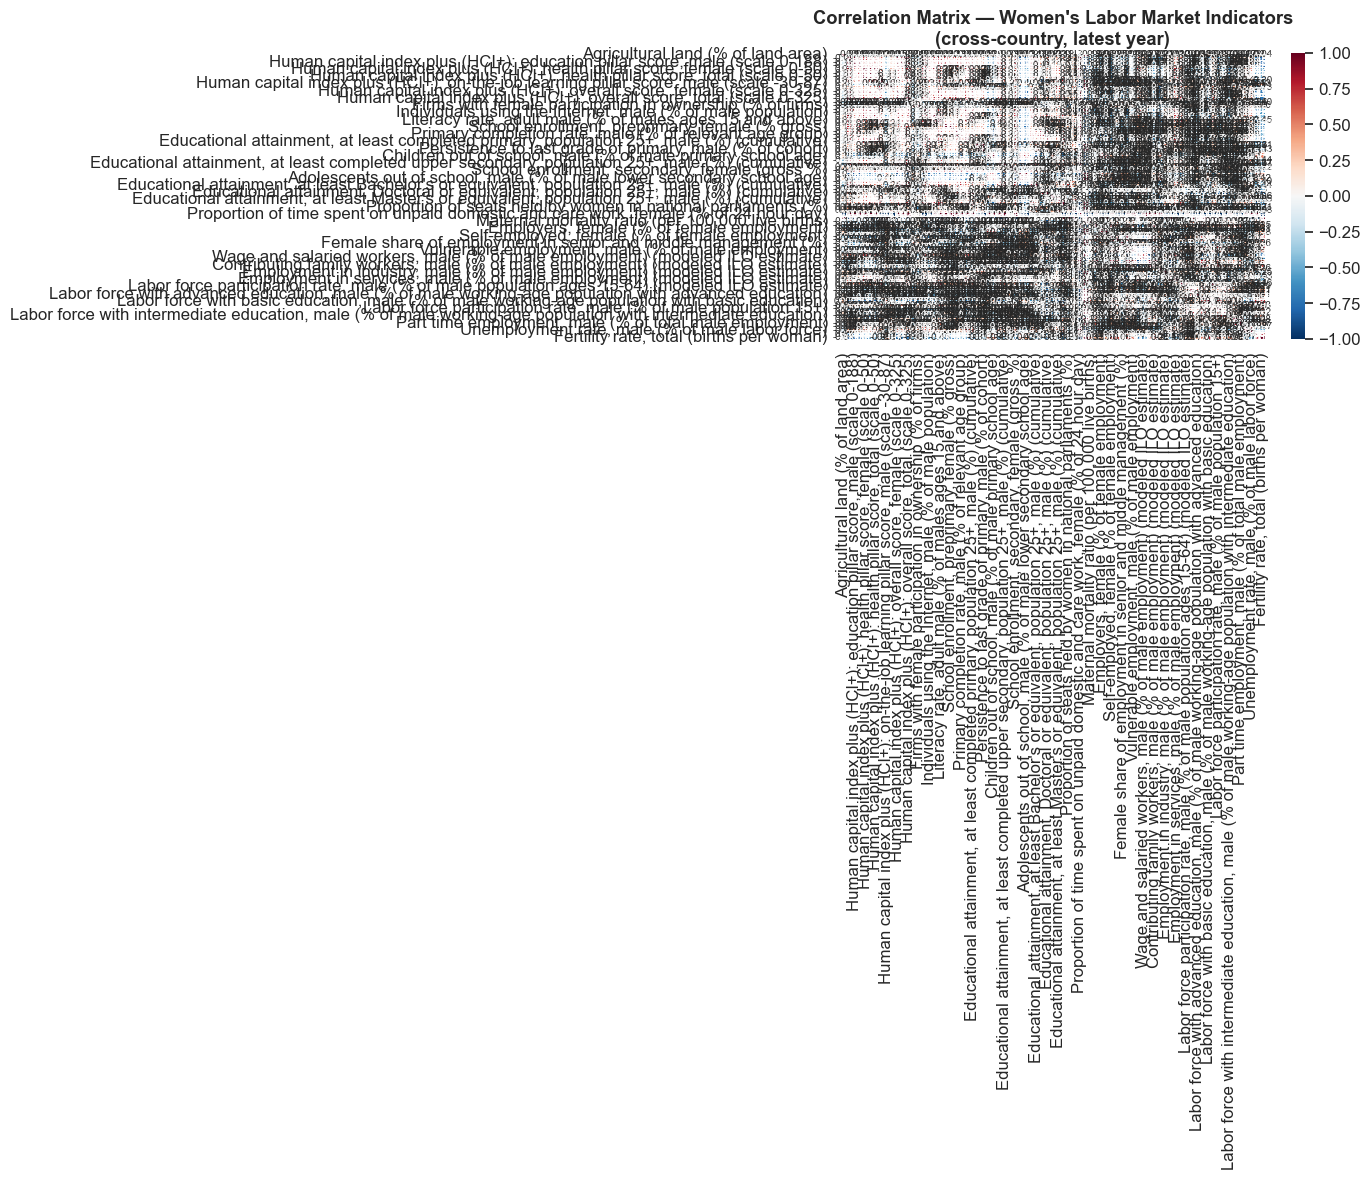

In [20]:
# Short names for readability in the heatmap
short_names = {
    "SL.TLF.CACT.FE.ZS": "LFP female",
    "SL.TLF.CACT.MA.ZS": "LFP male",
    "SL.TLF.CACT.FM.ZS": "LFP f/m ratio",
    "SL.UEM.TOTL.FE.ZS": "Unempl. female",
    "SL.UEM.TOTL.MA.ZS": "Unempl. male",
    "SL.EMP.VULN.FE.ZS": "Vuln. empl. female",
    "SL.EMP.VULN.MA.ZS": "Vuln. empl. male",
    "SL.EMP.SELF.FE.ZS": "Self-empl. female",
    "SL.EMP.MPYR.FE.ZS": "Employers female",
    "SL.EMP.WORK.FE.ZS": "Wage workers female",
    "SL.AGR.EMPL.FE.ZS": "Agric. empl. female",
    "SL.IND.EMPL.FE.ZS": "Industry empl. female",
    "SL.SRV.EMPL.FE.ZS": "Services empl. female",
    "SE.ADT.LITR.FE.ZS": "Literacy female",
    "SE.SEC.ENRR.FE":    "Secondary enroll. female",
    "SE.TER.ENRR.FE":    "Tertiary enroll. female",
    "SP.DYN.TFRT.IN":    "Fertility rate",
    "SH.STA.MMRT":       "Maternal mortality",
    "SG.GEN.PARL.ZS":    "Women in parliament",
    "IC.FRM.FEMM.ZS":    "Firms w/ female mgr",
}

short_names = INDICATORS

# Use df_wide which already has the latest-year pivot
corr_df = df_wide.set_index("country_code").drop(columns=["country_name"])
corr_df = corr_df.rename(columns=short_names)
corr_matrix = corr_df.corr()

mask = corr_matrix.isnull()  # hide pairs with no overlap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    ax=ax,
    annot_kws={"size": 7},
    vmin=-1, vmax=1,
)
ax.set_title("Correlation Matrix — Women's Labor Market Indicators\n(cross-country, latest year)", fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
corr_matrix.to_csv(
    "/Users/anapreciado/Desktop/github_repos/dataccion-agent/extraction/world_bank_corrmatrix.csv"
)